# USIA Team B — EDA and Validation of Parking Sites and Street Segment Data

**Datasets**
- `sites_db.csv` — consultant-generated reference dataset
- `street_segment_qtr_attributes.csv` — Infrastructure Victoria quarterly dataset

**Planner task:** EDA and Validation of Parking Sites and Street Segment Data
**Prepared by:** Tamil Elakkiya Ganapathi and Vasmai Avvaru

## Purpose

This notebook validates the two newly supplied datasets, applies the Product Owner's recommended within-street down/up filling for `InterventionType` and `InterventionSummary`, examines construction quarters and parking-capacity fields, checks relationships between the datasets, and exports analysis-ready files for Team B.

The notebook combines a reproducible technical workflow with short **Observations and Interpretation** sections after the major analyses. These explanations make the results easier for Team B members, project leaders, and assessors to understand.

> The quarterly dataset is treated as the authoritative source for construction periods. `sites_db.csv` is used as a contextual reference, as advised by Infrastructure Victoria.


## 1. Import libraries

In [1]:
import os
import re
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Upload the two CSV files

Run this cell and select:
- `sites_db.csv`
- `street_segment_qtr_attributes.csv`

In [2]:
from google.colab import files

uploaded = files.upload()

required = {"sites_db.csv", "street_segment_qtr_attributes.csv"}
missing = required - set(uploaded.keys())

if missing:
    raise FileNotFoundError(f"Please upload the missing file(s): {sorted(missing)}")

print("Uploaded files:", sorted(uploaded.keys()))

Saving sites_db.csv to sites_db.csv
Saving street_segment_qtr_attributes.csv to street_segment_qtr_attributes.csv
Uploaded files: ['sites_db.csv', 'street_segment_qtr_attributes.csv']


## 3. Read the CSV files safely

In [3]:
def read_csv_with_fallback(path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            df = pd.read_csv(path, encoding=encoding, low_memory=False)
            print(f"Loaded {path} using {encoding}")
            return df
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("Unable to decode file", b"", 0, 1, "Tried common encodings")

sites_raw = read_csv_with_fallback("sites_db.csv")
qtr_raw = read_csv_with_fallback("street_segment_qtr_attributes.csv")

print("sites_db shape:", sites_raw.shape)
print("quarterly dataset shape:", qtr_raw.shape)

Loaded sites_db.csv using cp1252
Loaded street_segment_qtr_attributes.csv using utf-8
sites_db shape: (637, 35)
quarterly dataset shape: (30783, 15)


## 4. Preserve raw copies and standardise column names

In [4]:
sites = sites_raw.copy()
qtr = qtr_raw.copy()

# Remove automatically exported index columns.
sites = sites.loc[:, ~sites.columns.str.match(r"^Unnamed")]
qtr = qtr.loc[:, ~qtr.columns.str.match(r"^Unnamed")]

# Strip accidental spaces from column names.
sites.columns = sites.columns.str.strip()
qtr.columns = qtr.columns.str.strip()

print("sites_db columns:")
print(sites.columns.tolist())

print("\nquarterly dataset columns:")
print(qtr.columns.tolist())

sites_db columns:
['InterventionID', 'SiteID', 'StreetSegmentID', 'SiteType', 'Baseline', 'StreetInScope', 'InterventionSiteID', 'DateOfIntervention/InitialCapture', 'DisruptionStartDate', 'DisruptionEndDate', 'InterventionType', 'NoChangeSince', 'StreetTrees', 'StreetTreesChange', 'StreetLighting', 'StreetLightingChange', 'StreetFurniture', 'StreetFurnitureChange', 'Placemaking', 'PlacemakingChange', 'Wayfinding', 'WayfindingChange', 'StreetInScopeOnStreetParking', 'StreetInScopeParkingFormat', 'StreetInScopeOnStreetParkingCapacity', 'BufferOnStreetParking', 'BufferOnStreetParkingFormat', 'BufferOnStreetParkingCapacity', 'OffStreetParking', 'OffStreetParkingCapacity', 'NumberOfTrafficLanes', 'PedestrianEstimatesAvgDay', 'InterventionSummary', 'InterventionSummaryExpanded', 'Comment']

quarterly dataset columns:
['QUARTER', 'SiteID', 'STREET_SEGMENT_ID', 'Baseline', 'InterventionType', 'InterventionSummary', 'is_under_construction', 'other_major_construction', 'StreetInScopeOnStreetPar

## 5. Dataset overview

In [5]:
overview = pd.DataFrame({
    "dataset": ["sites_db", "street_segment_qtr_attributes"],
    "rows": [len(sites), len(qtr)],
    "columns": [len(sites.columns), len(qtr.columns)],
    "duplicate_rows": [sites.duplicated().sum(), qtr.duplicated().sum()],
    "missing_cells": [int(sites.isna().sum().sum()), int(qtr.isna().sum().sum())]
})

display(overview)
display(sites.head())
display(qtr.head())

,dataset,rows,columns,duplicate_rows,missing_cells
0,sites_db,637,35,0,3573
1,street_segment_qtr_attributes,30783,14,0,103587


,InterventionID,SiteID,StreetSegmentID,SiteType,Baseline,StreetInScope,InterventionSiteID,DateOfIntervention/InitialCapture,DisruptionStartDate,DisruptionEndDate,InterventionType,NoChangeSince,StreetTrees,StreetTreesChange,StreetLighting,StreetLightingChange,StreetFurniture,StreetFurnitureChange,Placemaking,PlacemakingChange,Wayfinding,WayfindingChange,StreetInScopeOnStreetParking,StreetInScopeParkingFormat,StreetInScopeOnStreetParkingCapacity,BufferOnStreetParking,BufferOnStreetParkingFormat,BufferOnStreetParkingCapacity,OffStreetParking,OffStreetParkingCapacity,NumberOfTrafficLanes,PedestrianEstimatesAvgDay,InterventionSummary,InterventionSummaryExpanded,Comment
0,control_id_1_11903,control_id_1,11903,Control,Yes,LYGON STREET,NaN,20251015,NaN,NaN,Control,20091012.0,Yes,NaN,Yes,NaN,Yes,NaN,No,NaN,No,NaN,Yes,Parallel,105.0,Yes,Mixed,High,Yes,Low,2.0,2360.0,NA Control Site,NA Control Site,NaN
1,control_id_10_3391,control_id_10,3391,Control,Yes,HIGH STREET,NaN,20251015,NaN,NaN,Control,20180116.0,Yes,NaN,Yes,NaN,Yes,NaN,No,NaN,No,NaN,Yes,Parallel,152.0,Yes,Parallel,High,No,NaN,2.0,2230.0,NA Control Site,NA Control Site,No Change since 12102009
2,control_id_101_4175,control_id_101,4175,Control,Yes,MURRUMBEENA ROAD,NaN,20251004,NaN,NaN,Control,20190114.0,Yes,NaN,Yes,NaN,Yes,NaN,Yes,NaN,Yes,NaN,Yes,Parallel,7.0,Yes,Parallel,Medium,Yes,High,4.0,1390.0,NA Control Site,NA Control Site,"Site Parking - ~ 8 spots S of Railway Pde, Off..."
3,control_id_102_3813,control_id_102,3813,Control,Yes,WATTON STREET,NaN,20251015,NaN,NaN,Control,20210902.0,Yes,NoChange,Yes,NoChange,Yes,NoChange,Yes,NoChange,Yes,NoChange,Yes,Angled,237.0,Yes,Mixed,Medium,Yes,High,2.0,2730.0,NA Control Site,NA Control Site,2 additional parking bays added on Watton St i...
4,control_id_103_12024,control_id_103,12024,Control,Yes,ERROL ST,NaN,20251015,NaN,NaN,Control,20210901.0,Yes,NaN,Yes,NaN,Yes,NaN,Yes,NaN,Yes,NaN,Yes,Parallel,44.0,Yes,Mixed,High,Yes,Low,2.0,3620.0,NA Control site,NA Control Site,Jan 22 2021: Shopfront extended onto road whic...


,QUARTER,SiteID,STREET_SEGMENT_ID,Baseline,InterventionType,InterventionSummary,is_under_construction,other_major_construction,StreetInScopeOnStreetParking,StreetInScopeParkingFormat,StreetInScopeOnStreetParkingCap,BufferOnStreetParking,BufferOnStreetParkingCapacity,BufferOnStreetParkingFormat
0,9900Q2,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel
1,9900Q3,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel
2,9900Q4,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel
3,0001Q1,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel
4,0001Q2,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel


### Observations and Interpretation

- `sites_db.csv` contains **637 records and 35 columns**, while `street_segment_qtr_attributes.csv` contains **30,783 quarterly records**.
- The quarterly dataset has a much larger row count because each street segment is represented across multiple quarters.
- The two files have different analytical roles: the quarterly file supports time-based construction and parking analysis, while `sites_db.csv` provides supplementary site context.
- Neither dataset should be joined directly without first checking its record grain and identifier uniqueness.

## 6. Data types and missing-value assessment

In [6]:
def missing_report(df, dataset_name):
    report = pd.DataFrame({
        "column": df.columns,
        "data_type": df.dtypes.astype(str).values,
        "missing_values": df.isna().sum().values,
        "missing_percentage": (df.isna().mean().values * 100).round(2),
        "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
    })
    report.insert(0, "dataset", dataset_name)
    return report.sort_values(["missing_percentage", "column"], ascending=[False, True])

sites_missing = missing_report(sites, "sites_db")
qtr_missing = missing_report(qtr, "street_segment_qtr_attributes")

display(sites_missing)
display(qtr_missing)

,dataset,column,data_type,missing_values,missing_percentage,unique_values
6,sites_db,InterventionSiteID,float64,577,90.58,1
11,sites_db,NoChangeSince,float64,442,69.39,67
8,sites_db,DisruptionStartDate,float64,402,63.11,71
9,sites_db,DisruptionEndDate,float64,348,54.63,70
34,sites_db,Comment,object,334,52.43,160
19,sites_db,PlacemakingChange,object,240,37.68,3
13,sites_db,StreetTreesChange,object,228,35.79,4
15,sites_db,StreetLightingChange,object,226,35.48,3
17,sites_db,StreetFurnitureChange,object,224,35.16,3
21,sites_db,WayfindingChange,object,224,35.16,2


,dataset,column,data_type,missing_values,missing_percentage,unique_values
3,street_segment_qtr_attributes,Baseline,float64,30140,97.91,2
5,street_segment_qtr_attributes,InterventionSummary,object,30140,97.91,25
4,street_segment_qtr_attributes,InterventionType,object,30140,97.91,4
13,street_segment_qtr_attributes,BufferOnStreetParkingFormat,object,2837,9.22,5
11,street_segment_qtr_attributes,BufferOnStreetParking,float64,2626,8.53,2
12,street_segment_qtr_attributes,BufferOnStreetParkingCapacity,object,2626,8.53,4
6,street_segment_qtr_attributes,is_under_construction,float64,2626,8.53,2
7,street_segment_qtr_attributes,other_major_construction,float64,1575,5.12,2
9,street_segment_qtr_attributes,StreetInScopeParkingFormat,object,877,2.85,4
0,street_segment_qtr_attributes,QUARTER,object,0,0.00,105


### Observations and Interpretation

- Missingness is concentrated in contextual and intervention-description fields rather than in the core quarterly identifiers.
- In the quarterly dataset, the large number of missing `InterventionType` and `InterventionSummary` values reflects repeated quarterly rows where intervention details were not copied into every period.
- Missing values in `sites_db.csv` are expected in optional fields such as comments, disruption dates, and street-feature changes.
- Missing values should therefore be handled according to field meaning rather than by deleting all incomplete rows.

## 7. Standardise identifier fields

The two datasets use different capitalisation:
- `sites_db.StreetSegmentID`
- `street_segment_qtr_attributes.STREET_SEGMENT_ID`

Both are converted to nullable integers before validation.

In [7]:
sites["StreetSegmentID"] = pd.to_numeric(
    sites["StreetSegmentID"], errors="coerce"
).astype("Int64")

qtr["STREET_SEGMENT_ID"] = pd.to_numeric(
    qtr["STREET_SEGMENT_ID"], errors="coerce"
).astype("Int64")

print("Missing site segment IDs:", sites["StreetSegmentID"].isna().sum())
print("Missing quarterly segment IDs:", qtr["STREET_SEGMENT_ID"].isna().sum())

print("Unique segment IDs in sites_db:", sites["StreetSegmentID"].nunique())
print("Unique segment IDs in quarterly dataset:", qtr["STREET_SEGMENT_ID"].nunique())

Missing site segment IDs: 0
Missing quarterly segment IDs: 0
Unique segment IDs in sites_db: 274
Unique segment IDs in quarterly dataset: 292


## 8. Validate duplicate keys and record grain

In [8]:
key_validation = pd.DataFrame({
    "dataset": ["sites_db", "quarterly"],
    "rows": [len(sites), len(qtr)],
    "unique_segment_ids": [
        sites["StreetSegmentID"].nunique(),
        qtr["STREET_SEGMENT_ID"].nunique()
    ],
    "duplicate_segment_id_rows": [
        sites["StreetSegmentID"].duplicated(keep=False).sum(),
        qtr["STREET_SEGMENT_ID"].duplicated(keep=False).sum()
    ]
})

display(key_validation)

# Quarterly records should normally be unique by segment and quarter.
qtr_key_duplicates = qtr.duplicated(
    subset=["STREET_SEGMENT_ID", "QUARTER"], keep=False
)

print("Duplicate segment-quarter rows:", int(qtr_key_duplicates.sum()))

if qtr_key_duplicates.any():
    display(
        qtr.loc[qtr_key_duplicates]
        .sort_values(["STREET_SEGMENT_ID", "QUARTER"])
        .head(30)
    )

,dataset,rows,unique_segment_ids,duplicate_segment_id_rows
0,sites_db,637,274,442
1,quarterly,30783,292,30783


Duplicate segment-quarter rows: 246


,QUARTER,SiteID,STREET_SEGMENT_ID,Baseline,InterventionType,InterventionSummary,is_under_construction,other_major_construction,StreetInScopeOnStreetParking,StreetInScopeParkingFormat,StreetInScopeOnStreetParkingCap,BufferOnStreetParking,BufferOnStreetParkingCapacity,BufferOnStreetParkingFormat
4609,2122Q2,42,123,1.0,ProtectedBikeLane,No bike lane of any type,1.0,1.0,1,Mixed,42,1.0,High,Mixed
4610,2122Q2,42,123,0.0,ProtectedBikeLane,Protected bike lane,1.0,1.0,1,Parallel,27,1.0,High,Mixed
4715,2122Q2,42,124,1.0,ProtectedBikeLane,No bike lane of any type,1.0,1.0,1,Angled,58,1.0,High,Mixed
4716,2122Q2,42,124,0.0,ProtectedBikeLane,Protected bike lane (open one direction),1.0,1.0,1,Angled,44,1.0,High,Mixed
4821,2122Q2,42,125,1.0,ProtectedBikeLane,No bike lane of any type,1.0,1.0,1,Mixed,63,1.0,High,Mixed
4822,2122Q2,42,125,0.0,ProtectedBikeLane,Protected bike lane,1.0,1.0,1,Mixed,60,1.0,High,Mixed
3131,2021Q4,34,3124,1.0,ProtectedBikeLane,Painted bike lane,1.0,1.0,1,Mixed,50,1.0,Low,Parallel
3132,2021Q4,34,3124,0.0,ProtectedBikeLane,Protected bike lane,1.0,1.0,1,Parallel,34,1.0,Low,Parallel
12830,0001Q1,control_id_131,3372,NaN,NaN,NaN,0.0,0.0,1,Parallel,65,1.0,High,Parallel
28577,0001Q1,48,3372,NaN,NaN,NaN,NaN,NaN,1,Parallel,66,NaN,NaN,NaN


### Observations and Interpretation

- No duplicate full rows were identified in either dataset.
- The quarterly dataset contains **246 duplicated `STREET_SEGMENT_ID`–`QUARTER` combinations**.
- These are not necessarily identical records and may represent multiple observations or state changes within the same quarter.
- They should be reviewed before modelling or aggregation so valid records are not removed incorrectly.

## 9. Parse and order quarter labels

Labels such as `9900Q2` are interpreted as a financial-year-style period starting in 1999 and ending in 2000. This parsing is used only to sort the quarterly records consistently; the original `QUARTER` field is retained.

In [9]:
quarter_pattern = re.compile(r"^(\d{2})(\d{2})Q([1-4])$")

def parse_quarter_label(value):
    if pd.isna(value):
        return pd.Series([pd.NA, pd.NA, pd.NA], dtype="Int64")

    match = quarter_pattern.match(str(value).strip())
    if not match:
        return pd.Series([pd.NA, pd.NA, pd.NA], dtype="Int64")

    start_yy, end_yy, quarter = map(int, match.groups())
    start_year = 1900 + start_yy if start_yy >= 90 else 2000 + start_yy
    end_year = 1900 + end_yy if end_yy >= 90 else 2000 + end_yy

    # Handle century crossover such as 1999–2000.
    if end_year < start_year:
        end_year += 100

    sort_key = start_year * 10 + quarter
    return pd.Series([start_year, end_year, sort_key], dtype="Int64")

parsed = qtr["QUARTER"].apply(parse_quarter_label)
parsed.columns = ["quarter_start_year", "quarter_end_year", "quarter_sort_key"]

qtr = pd.concat([qtr, parsed], axis=1)

print("Unparsed quarter labels:", qtr["quarter_sort_key"].isna().sum())
print("Quarter range:")
display(
    qtr.loc[:, ["QUARTER", "quarter_start_year", "quarter_end_year", "quarter_sort_key"]]
    .drop_duplicates()
    .sort_values("quarter_sort_key")
    .head()
)
display(
    qtr.loc[:, ["QUARTER", "quarter_start_year", "quarter_end_year", "quarter_sort_key"]]
    .drop_duplicates()
    .sort_values("quarter_sort_key")
    .tail()
)

Unparsed quarter labels: 0
Quarter range:


,QUARTER,quarter_start_year,quarter_end_year,quarter_sort_key
0,9900Q2,1999,2000,19992
1,9900Q3,1999,2000,19993
2,9900Q4,1999,2000,19994
3,0001Q1,2000,2001,20001
4,0001Q2,2000,2001,20002


,QUARTER,quarter_start_year,quarter_end_year,quarter_sort_key
100,2425Q2,2024,2025,20242
101,2425Q3,2024,2025,20243
102,2425Q4,2024,2025,20244
103,2526Q1,2025,2026,20251
104,2526Q2,2025,2026,20252


## 10. Apply the Product Owner's recommended down/up fill

`InterventionType` and `InterventionSummary` are filled **within each street segment only**, after sorting records by quarter. This prevents values from being carried across unrelated street segments.

Both the original and filled columns are retained for traceability.

In [10]:
qtr = qtr.sort_values(
    ["STREET_SEGMENT_ID", "quarter_sort_key", "QUARTER"],
    na_position="last"
).reset_index(drop=True)

qtr["InterventionType_original"] = qtr["InterventionType"]
qtr["InterventionSummary_original"] = qtr["InterventionSummary"]

fill_columns = ["InterventionType", "InterventionSummary"]

before_fill = qtr[fill_columns].isna().sum()

qtr[fill_columns] = (
    qtr.groupby("STREET_SEGMENT_ID", dropna=False)[fill_columns]
    .transform(lambda group: group.ffill().bfill())
)

after_fill = qtr[fill_columns].isna().sum()

fill_summary = pd.DataFrame({
    "column": fill_columns,
    "missing_before": before_fill.values,
    "missing_after": after_fill.values,
    "values_filled": (before_fill - after_fill).values
})

display(fill_summary)

,column,missing_before,missing_after,values_filled
0,InterventionType,30140,0,30140
1,InterventionSummary,30140,0,30140


### Observations and Interpretation

- Before filling, both `InterventionType` and `InterventionSummary` contained **30,140 missing values**.
- Applying forward fill followed by backward fill **within each street segment** reduced missing values in both fields to **zero**.
- Grouping by `STREET_SEGMENT_ID` is essential because an unrestricted fill could incorrectly transfer intervention details between unrelated streets.
- The original columns are retained for traceability, allowing the team to distinguish supplied values from filled values.

## 11. Validate consistency after filling

In [11]:
def segment_conflict_report(df, column):
    counts = (
        df.groupby("STREET_SEGMENT_ID")[column]
        .nunique(dropna=True)
        .reset_index(name="unique_non_null_values")
    )
    return counts[counts["unique_non_null_values"] > 1]

type_conflicts = segment_conflict_report(qtr, "InterventionType")
summary_conflicts = segment_conflict_report(qtr, "InterventionSummary")

print("Segments with more than one InterventionType:", len(type_conflicts))
print("Segments with more than one InterventionSummary:", len(summary_conflicts))

display(type_conflicts.head(20))
display(summary_conflicts.head(20))

Segments with more than one InterventionType: 1
Segments with more than one InterventionSummary: 85


,STREET_SEGMENT_ID,unique_non_null_values
72,3372,2


,STREET_SEGMENT_ID,unique_non_null_values
0,123,3
1,124,3
2,125,3
8,858,2
9,859,2
16,1587,4
19,1659,5
20,1660,5
21,1661,6
22,1662,4


## 12. Construction-period analysis

In [12]:
qtr["is_under_construction"] = pd.to_numeric(
    qtr["is_under_construction"], errors="coerce"
).astype("Int64")

construction_counts = (
    qtr["is_under_construction"]
    .value_counts(dropna=False)
    .rename_axis("is_under_construction")
    .reset_index(name="records")
)

display(construction_counts)

construction_periods = (
    qtr[qtr["is_under_construction"].eq(1)]
    .groupby("STREET_SEGMENT_ID")
    .agg(
        first_construction_quarter=("quarter_sort_key", "min"),
        last_construction_quarter=("quarter_sort_key", "max"),
        construction_quarter_count=("QUARTER", "nunique"),
        intervention_type=("InterventionType", "first"),
        intervention_summary=("InterventionSummary", "first")
    )
    .reset_index()
)

# Restore original quarter labels for first and last construction periods.
quarter_lookup = (
    qtr[["quarter_sort_key", "QUARTER"]]
    .dropna()
    .drop_duplicates("quarter_sort_key")
)

construction_periods = construction_periods.merge(
    quarter_lookup.rename(columns={
        "quarter_sort_key": "first_construction_quarter",
        "QUARTER": "first_construction_quarter_label"
    }),
    on="first_construction_quarter",
    how="left"
).merge(
    quarter_lookup.rename(columns={
        "quarter_sort_key": "last_construction_quarter",
        "QUARTER": "last_construction_quarter_label"
    }),
    on="last_construction_quarter",
    how="left"
)

display(construction_periods.head(20))
print("Segments with at least one construction quarter:", len(construction_periods))

,is_under_construction,records
0,0,27968
1,<NA>,2626
2,1,189


,STREET_SEGMENT_ID,first_construction_quarter,last_construction_quarter,construction_quarter_count,intervention_type,intervention_summary,first_construction_quarter_label,last_construction_quarter_label
0,123,20212,20212,1,ProtectedBikeLane,No bike lane of any type,2122Q2,2122Q2
1,124,20212,20234,3,ProtectedBikeLane,No bike lane of any type,2122Q2,2324Q4
2,125,20212,20212,1,ProtectedBikeLane,No bike lane of any type,2122Q2,2122Q2
3,858,20203,20204,2,ProtectedBikeLane,Painted bike lane,2021Q3,2021Q4
4,1659,20201,20202,2,ProtectedBikeLane,Pre-protected bike lane (minor change),2021Q1,2021Q2
5,1660,20201,20202,2,ProtectedBikeLane,Pre-protected bike lane (no change),2021Q1,2021Q2
6,1661,20201,20202,2,ProtectedBikeLane,Pre-protected bike lane (no change),2021Q1,2021Q2
7,1662,20124,20131,2,ProtectedBikeLane,Pre-protected bike lane (minor change),1213Q4,1314Q1
8,1663,20124,20131,2,ProtectedBikeLane,Pre-protected bike lane (minor change),1213Q4,1314Q1
9,1753,20102,20104,3,ProtectedBikeLane,Painted bike lane,1011Q2,1011Q4


Segments with at least one construction quarter: 69


### Observations and Interpretation

- **69 street segments** contain at least one quarter marked as under construction.
- Construction periods extend from **0708Q2** to **2425Q4**, showing that the study includes both older and recent interventions.
- The `is_under_construction` field should be used as the authoritative basis for defining construction windows.
- Baseline and post-intervention periods should be selected relative to these quarters and checked against the availability of imagery or sensor records.

## 13. Intervention-type analysis

,InterventionType,street_segments
0,Control,193
2,ProtectedBikeLane,69
3,Regional Reallocation,25
1,Pedestrianisation,6


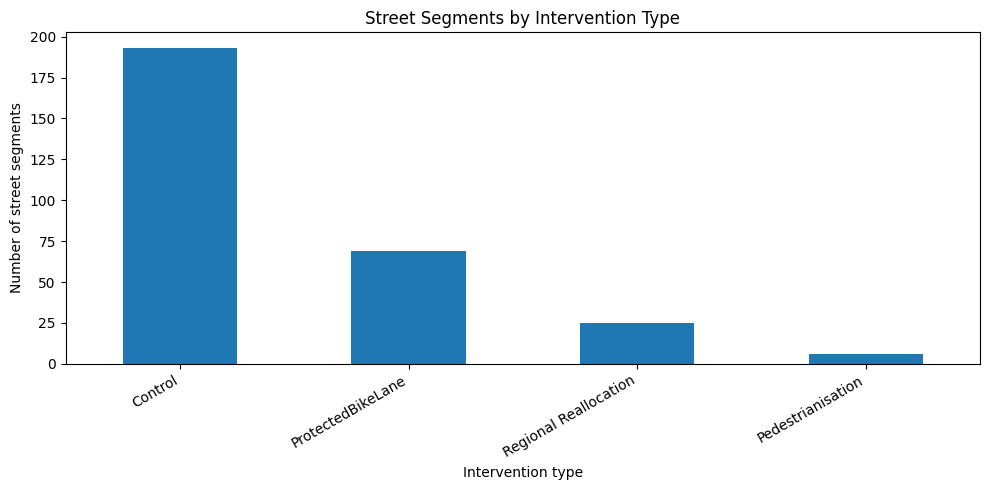

In [13]:
intervention_summary = (
    qtr[["STREET_SEGMENT_ID", "InterventionType"]]
    .drop_duplicates()
    .groupby("InterventionType", dropna=False)
    .agg(street_segments=("STREET_SEGMENT_ID", "nunique"))
    .reset_index()
    .sort_values("street_segments", ascending=False)
)

display(intervention_summary)

ax = intervention_summary.dropna(subset=["InterventionType"]).plot(
    kind="bar",
    x="InterventionType",
    y="street_segments",
    legend=False,
    figsize=(10, 5),
    title="Street Segments by Intervention Type"
)
ax.set_xlabel("Intervention type")
ax.set_ylabel("Number of street segments")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Observations and Interpretation

- The intervention categories cover protected bike lanes, controls, regional reallocations, and pedestrian interventions.
- Protected bike lanes are the main treatment type relevant to Team B's research question.
- Control segments should be retained for later comparison so that broader temporal changes are not incorrectly attributed to the intervention.
- Intervention labels should be standardised before grouping because formatting differences can create artificial categories.

## 14. Parking-capacity validation and analysis

,field,missing_values,unique_values
0,StreetInScopeOnStreetParkingCap,0,135
1,BufferOnStreetParkingCapacity,2626,4


Negative street-in-scope parking capacities: 0


,value
count,30783.000000
mean,59.061982
std,52.064876
min,0.000000
25%,24.000000
50%,47.000000
75%,75.000000
max,293.000000


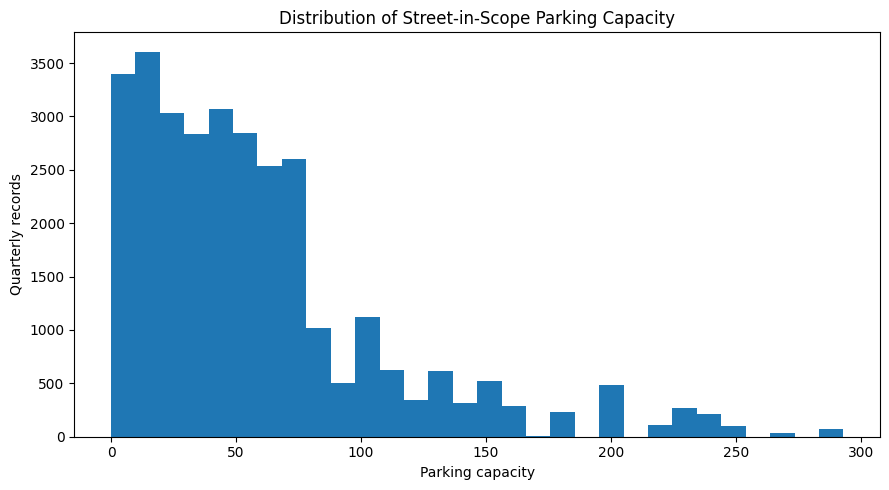

In [14]:
parking_columns = [
    "StreetInScopeOnStreetParkingCap",
    "BufferOnStreetParkingCapacity"
]

# Street-in-scope capacity is numeric in the supplied quarterly dataset.
qtr["StreetInScopeOnStreetParkingCap"] = pd.to_numeric(
    qtr["StreetInScopeOnStreetParkingCap"], errors="coerce"
)

parking_validation = pd.DataFrame({
    "field": parking_columns,
    "missing_values": [qtr[col].isna().sum() for col in parking_columns],
    "unique_values": [qtr[col].nunique(dropna=True) for col in parking_columns]
})

display(parking_validation)

negative_capacity = qtr["StreetInScopeOnStreetParkingCap"].lt(0).sum()
print("Negative street-in-scope parking capacities:", int(negative_capacity))

display(
    qtr["StreetInScopeOnStreetParkingCap"]
    .describe()
    .to_frame("value")
)

ax = qtr["StreetInScopeOnStreetParkingCap"].dropna().plot(
    kind="hist",
    bins=30,
    figsize=(9, 5),
    title="Distribution of Street-in-Scope Parking Capacity"
)
ax.set_xlabel("Parking capacity")
ax.set_ylabel("Quarterly records")
plt.tight_layout()
plt.show()

### Observations and Interpretation

- Street-in-scope parking capacity ranges from **0 to 293 spaces**, with an average of approximately **59.06 spaces**.
- A capacity of zero may be valid for streets without on-street parking but should be checked against parking-availability fields.
- Parking-capacity distributions are uneven, so median and segment-level comparisons are more informative than the mean alone.
- Parking capacity measures supply, not utilisation; occupancy observations or imagery-derived vehicle counts are still required.

## 15. Parking-capacity patterns by intervention type

In [15]:
parking_by_intervention = (
    qtr.groupby("InterventionType", dropna=False)
    ["StreetInScopeOnStreetParkingCap"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
    .round(2)
)

display(parking_by_intervention)

segment_capacity = (
    qtr.groupby(["STREET_SEGMENT_ID", "InterventionType"], dropna=False)
    ["StreetInScopeOnStreetParkingCap"]
    .agg(
        minimum_capacity="min",
        maximum_capacity="max",
        first_capacity="first",
        last_capacity="last"
    )
    .reset_index()
)

segment_capacity["capacity_change"] = (
    segment_capacity["last_capacity"] - segment_capacity["first_capacity"]
)

display(
    segment_capacity.sort_values("capacity_change").head(20)
)

,InterventionType,count,mean,median,min,max
0,Control,20162,57.23,49.0,0,245
1,Pedestrianisation,630,9.25,7.0,0,30
2,ProtectedBikeLane,7262,46.31,37.0,0,293
3,Regional Reallocation,2729,118.03,110.0,0,229


,STREET_SEGMENT_ID,InterventionType,minimum_capacity,maximum_capacity,first_capacity,last_capacity,capacity_change
175,6290,ProtectedBikeLane,91,158,158,91,-67
221,9168,ProtectedBikeLane,75,136,136,75,-61
165,5883,ProtectedBikeLane,48,106,106,48,-58
253,10838,ProtectedBikeLane,23,75,75,23,-52
204,7327,ProtectedBikeLane,11,62,62,11,-51
99,3752,Regional Reallocation,0,229,229,181,-48
100,3753,Regional Reallocation,0,229,229,181,-48
97,3750,Regional Reallocation,0,229,229,181,-48
98,3751,Regional Reallocation,0,229,229,181,-48
203,7326,ProtectedBikeLane,39,80,80,39,-41


## 16. Review `sites_db.csv` as a contextual reference

In [16]:
sites["InterventionType"] = sites["InterventionType"].astype("string").str.strip()
sites["InterventionSummary"] = sites["InterventionSummary"].astype("string").str.strip()

sites_intervention_summary = (
    sites.groupby("InterventionType", dropna=False)
    .agg(
        records=("StreetSegmentID", "size"),
        unique_segments=("StreetSegmentID", "nunique")
    )
    .reset_index()
    .sort_values("records", ascending=False)
)

display(sites_intervention_summary)

date_columns = [
    "DateOfIntervention/InitialCapture",
    "DisruptionStartDate",
    "DisruptionEndDate"
]

date_review = pd.DataFrame({
    "field": date_columns,
    "non_null_values": [sites[col].notna().sum() for col in date_columns],
    "unique_values": [sites[col].nunique(dropna=True) for col in date_columns]
})

display(date_review)

,InterventionType,records,unique_segments
2,ProtectedBikeLane,416,71
0,Control,195,195
3,Regional Reallocation,12,2
1,Pedestrianisation,9,6
4,<NA>,5,5


,field,non_null_values,unique_values
0,DateOfIntervention/InitialCapture,637,82
1,DisruptionStartDate,235,71
2,DisruptionEndDate,289,70


### Observations and Interpretation

- `sites_db.csv` provides useful contextual attributes, including intervention descriptions, disruption dates, parking characteristics, comments, and changes to street features.
- It contains multiple records for some street segments, so it should not be treated as a one-row-per-segment analytical table.
- The Product Owner advised using this file mainly as a reference because its intervention dates require interpretation.
- The comments and intervention summaries can help explain unusual parking-capacity or construction patterns identified in the quarterly data.

## 17. Validate relationships between the two datasets

Because `sites_db.csv` can contain multiple records for a street segment, this section compares unique segment IDs rather than performing an uncontrolled many-to-many row join.

In [17]:
site_keys = set(sites["StreetSegmentID"].dropna().astype(int))
qtr_keys = set(qtr["STREET_SEGMENT_ID"].dropna().astype(int))

join_report = pd.DataFrame({
    "measure": [
        "Unique segments in sites_db",
        "Unique segments in quarterly dataset",
        "Segments present in both datasets",
        "Segments only in sites_db",
        "Segments only in quarterly dataset",
        "Quarterly segment match percentage"
    ],
    "value": [
        len(site_keys),
        len(qtr_keys),
        len(site_keys & qtr_keys),
        len(site_keys - qtr_keys),
        len(qtr_keys - site_keys),
        round(len(site_keys & qtr_keys) / len(qtr_keys) * 100, 2) if qtr_keys else np.nan
    ]
})

display(join_report)

sites_only_ids = sorted(site_keys - qtr_keys)
qtr_only_ids = sorted(qtr_keys - site_keys)

print("First sites_db-only IDs:", sites_only_ids[:20])
print("First quarterly-only IDs:", qtr_only_ids[:20])

,measure,value
0,Unique segments in sites_db,274.00
1,Unique segments in quarterly dataset,292.00
2,Segments present in both datasets,269.00
3,Segments only in sites_db,5.00
4,Segments only in quarterly dataset,23.00
5,Quarterly segment match percentage,92.12


First sites_db-only IDs: [3500, 3794, 3830, 5640, 11482]
First quarterly-only IDs: [1563, 1586, 1587, 2559, 3504, 3750, 3751, 3752, 3753, 5753, 6237, 6708, 6709, 7072, 7115, 7336, 7851, 9011, 9649, 9650]


### Observations and Interpretation

- `sites_db.csv` contains **274 unique street segments**, while the quarterly dataset contains **292**.
- **269 segment IDs** occur in both datasets, giving a quarterly-dataset match rate of approximately **92.12%**.
- Five segment IDs occur only in `sites_db.csv`, and 23 occur only in the quarterly dataset.
- Unmatched IDs should be documented rather than automatically removed because each file has a different purpose and coverage.

## 18. Create a one-row-per-segment reference table from `sites_db.csv`

A direct join could duplicate quarterly rows because `sites_db.csv` has multiple records per segment. The code below creates a controlled reference summary first.

In [18]:
def first_non_null(series):
    non_null = series.dropna()
    return non_null.iloc[0] if len(non_null) else pd.NA

site_reference = (
    sites.groupby("StreetSegmentID", dropna=False)
    .agg(
        site_record_count=("StreetSegmentID", "size"),
        reference_site_id=("SiteID", first_non_null),
        reference_intervention_type=("InterventionType", first_non_null),
        reference_intervention_summary=("InterventionSummary", first_non_null),
        reference_date_of_intervention=("DateOfIntervention/InitialCapture", first_non_null),
        reference_disruption_start=("DisruptionStartDate", first_non_null),
        reference_disruption_end=("DisruptionEndDate", first_non_null),
        reference_comment=("Comment", first_non_null)
    )
    .reset_index()
    .rename(columns={"StreetSegmentID": "STREET_SEGMENT_ID"})
)

qtr_enriched = qtr.merge(
    site_reference,
    on="STREET_SEGMENT_ID",
    how="left",
    validate="many_to_one"
)

print("Enriched quarterly shape:", qtr_enriched.shape)
print(
    "Quarterly rows without sites_db reference:",
    qtr_enriched["site_record_count"].isna().sum()
)

display(qtr_enriched.head())

Enriched quarterly shape: (30783, 27)
Quarterly rows without sites_db reference: 2416


,QUARTER,SiteID,STREET_SEGMENT_ID,Baseline,InterventionType,InterventionSummary,is_under_construction,other_major_construction,StreetInScopeOnStreetParking,StreetInScopeParkingFormat,StreetInScopeOnStreetParkingCap,BufferOnStreetParking,BufferOnStreetParkingCapacity,BufferOnStreetParkingFormat,quarter_start_year,quarter_end_year,quarter_sort_key,InterventionType_original,InterventionSummary_original,site_record_count,reference_site_id,reference_intervention_type,reference_intervention_summary,reference_date_of_intervention,reference_disruption_start,reference_disruption_end,reference_comment
0,9900Q2,42,123,NaN,ProtectedBikeLane,No bike lane of any type,0,0.0,1,Mixed,42,1.0,High,Mixed,1999,2000,19992,NaN,NaN,3,site_id_42,ProtectedBikeLane,No bike lane of any type,20211006.0,20211006.0,20211122.0,<NA>
1,9900Q3,42,123,NaN,ProtectedBikeLane,No bike lane of any type,0,0.0,1,Mixed,42,1.0,High,Mixed,1999,2000,19993,NaN,NaN,3,site_id_42,ProtectedBikeLane,No bike lane of any type,20211006.0,20211006.0,20211122.0,<NA>
2,9900Q4,42,123,NaN,ProtectedBikeLane,No bike lane of any type,0,0.0,1,Mixed,42,1.0,High,Mixed,1999,2000,19994,NaN,NaN,3,site_id_42,ProtectedBikeLane,No bike lane of any type,20211006.0,20211006.0,20211122.0,<NA>
3,0001Q1,42,123,NaN,ProtectedBikeLane,No bike lane of any type,0,0.0,1,Mixed,42,1.0,High,Mixed,2000,2001,20001,NaN,NaN,3,site_id_42,ProtectedBikeLane,No bike lane of any type,20211006.0,20211006.0,20211122.0,<NA>
4,0001Q2,42,123,NaN,ProtectedBikeLane,No bike lane of any type,0,0.0,1,Mixed,42,1.0,High,Mixed,2000,2001,20002,NaN,NaN,3,site_id_42,ProtectedBikeLane,No bike lane of any type,20211006.0,20211006.0,20211122.0,<NA>


## 19. Cross-dataset intervention-type consistency

In [19]:
type_consistency = (
    qtr_enriched[
        ["STREET_SEGMENT_ID", "InterventionType", "reference_intervention_type"]
    ]
    .drop_duplicates()
    .copy()
)

type_consistency["normalised_qtr_type"] = (
    type_consistency["InterventionType"]
    .astype("string")
    .str.replace(r"\s+", "", regex=True)
    .str.lower()
)

type_consistency["normalised_site_type"] = (
    type_consistency["reference_intervention_type"]
    .astype("string")
    .str.replace(r"\s+", "", regex=True)
    .str.lower()
)

type_consistency["type_matches"] = (
    type_consistency["normalised_qtr_type"]
    == type_consistency["normalised_site_type"]
)

display(type_consistency["type_matches"].value_counts(dropna=False))

display(
    type_consistency[
        type_consistency["type_matches"].eq(False)
        & type_consistency["normalised_qtr_type"].notna()
        & type_consistency["normalised_site_type"].notna()
    ].head(30)
)

,count
type_matches,
True,269
<NA>,23
False,1


,STREET_SEGMENT_ID,InterventionType,reference_intervention_type,normalised_qtr_type,normalised_site_type,type_matches
7564,3372,Regional Reallocation,Control,regionalreallocation,control,False


### Observations and Interpretation

- Intervention classifications are highly consistent across the two datasets.
- Only **street segment 3372** was identified with a conflicting intervention classification.
- This segment should be checked against the original Product Owner files or clarified with Infrastructure Victoria before final analysis.
- Normalising case and whitespace before comparison prevents formatting differences from being mistaken for true conflicts.

## 20. Create construction timeline summary

,quarter_sort_key,QUARTER,street_segments_under_construction
0,20072,0708Q2,2
1,20073,0708Q3,2
2,20074,0708Q4,2
3,20081,0809Q1,2
4,20082,0809Q2,2
5,20083,0809Q3,2
6,20084,0809Q4,2
7,20091,0910Q1,2
8,20092,0910Q2,2
9,20094,0910Q4,3


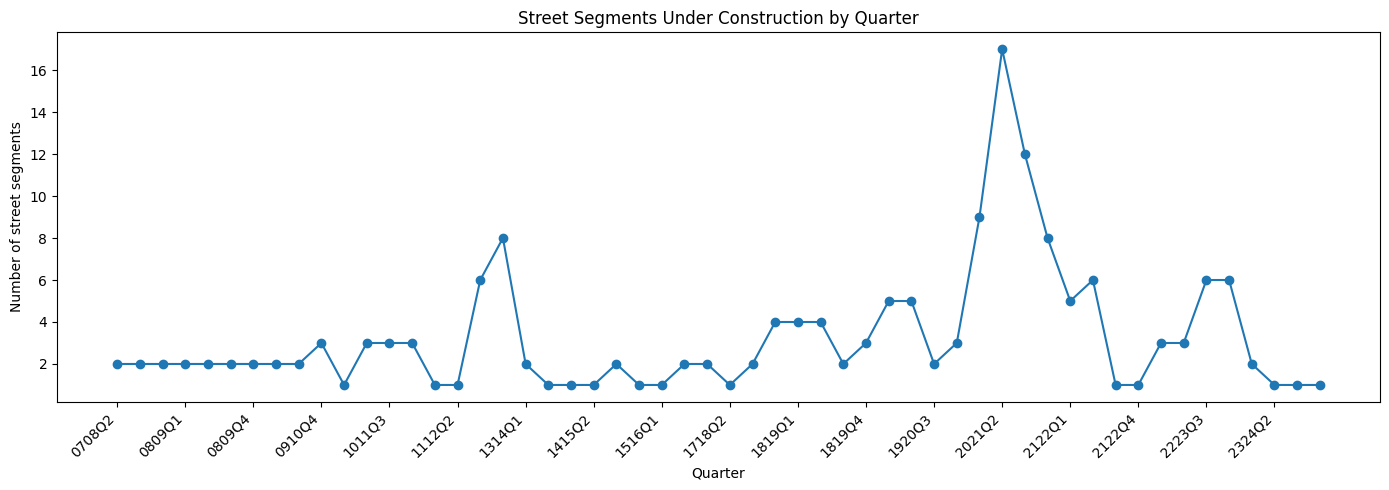

In [20]:
construction_by_quarter = (
    qtr[qtr["is_under_construction"].eq(1)]
    .groupby(["quarter_sort_key", "QUARTER"])
    .agg(
        street_segments_under_construction=("STREET_SEGMENT_ID", "nunique")
    )
    .reset_index()
    .sort_values("quarter_sort_key")
)

display(construction_by_quarter)

if not construction_by_quarter.empty:
    ax = construction_by_quarter.plot(
        kind="line",
        x="QUARTER",
        y="street_segments_under_construction",
        marker="o",
        figsize=(14, 5),
        legend=False,
        title="Street Segments Under Construction by Quarter"
    )
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Number of street segments")

    # Reduce overcrowding while preserving the full series.
    tick_step = max(1, len(construction_by_quarter) // 15)
    ax.set_xticks(range(0, len(construction_by_quarter), tick_step))
    ax.set_xticklabels(
        construction_by_quarter["QUARTER"].iloc[::tick_step],
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

### Observations and Interpretation

- The quarterly timeline shows how many distinct street segments were under construction in each period.
- Construction activity is concentrated in particular intervention years rather than being evenly distributed across the full time series.
- This chart can guide the selection of before-and-after observation windows and reveal quarters where several sites were simultaneously affected.
- Any comparison using imagery must acknowledge that Nearmap capture dates may not align exactly with the authoritative construction quarters.

## 21. Build data-quality summary

In [21]:
quality_summary = pd.DataFrame({
    "check": [
        "sites_db rows",
        "quarterly rows",
        "sites_db duplicate full rows",
        "quarterly duplicate full rows",
        "duplicate segment-quarter rows",
        "unique sites_db segments",
        "unique quarterly segments",
        "matched segment IDs",
        "quarterly-only segment IDs",
        "sites_db-only segment IDs",
        "missing InterventionType after fill",
        "missing InterventionSummary after fill",
        "segments with construction activity"
    ],
    "result": [
        len(sites),
        len(qtr),
        int(sites.duplicated().sum()),
        int(qtr.duplicated().sum()),
        int(qtr_key_duplicates.sum()),
        sites["StreetSegmentID"].nunique(),
        qtr["STREET_SEGMENT_ID"].nunique(),
        len(site_keys & qtr_keys),
        len(qtr_keys - site_keys),
        len(site_keys - qtr_keys),
        int(qtr["InterventionType"].isna().sum()),
        int(qtr["InterventionSummary"].isna().sum()),
        len(construction_periods)
    ]
})

display(quality_summary)

,check,result
0,sites_db rows,637
1,quarterly rows,30783
2,sites_db duplicate full rows,0
3,quarterly duplicate full rows,0
4,duplicate segment-quarter rows,246
5,unique sites_db segments,274
6,unique quarterly segments,292
7,matched segment IDs,269
8,quarterly-only segment IDs,23
9,sites_db-only segment IDs,5


### Overall Data-Quality Interpretation

- The two datasets are suitable for continued Team B analysis after the documented validation and filling steps.
- The quarterly dataset is the preferred analytical source for construction timing and parking capacity.
- Important issues remaining for review are the 246 duplicate segment-quarter combinations, unmatched IDs between files, and the single intervention-type conflict.
- The exported validated and enriched files provide a reproducible basis for spatial joins, visualisation, and later before-and-after analysis.

## 22. Export validated outputs

In [22]:
output_dir = "/content/usia_new_dataset_outputs"
os.makedirs(output_dir, exist_ok=True)

sites_missing.to_csv(
    os.path.join(output_dir, "sites_db_missing_value_report.csv"),
    index=False
)
qtr_missing.to_csv(
    os.path.join(output_dir, "quarterly_missing_value_report_before_fill.csv"),
    index=False
)
fill_summary.to_csv(
    os.path.join(output_dir, "intervention_fill_summary.csv"),
    index=False
)
join_report.to_csv(
    os.path.join(output_dir, "cross_dataset_join_report.csv"),
    index=False
)
construction_periods.to_csv(
    os.path.join(output_dir, "construction_periods_by_segment.csv"),
    index=False
)
construction_by_quarter.to_csv(
    os.path.join(output_dir, "construction_activity_by_quarter.csv"),
    index=False
)
intervention_summary.to_csv(
    os.path.join(output_dir, "intervention_type_summary.csv"),
    index=False
)
parking_by_intervention.to_csv(
    os.path.join(output_dir, "parking_capacity_by_intervention.csv"),
    index=False
)
segment_capacity.to_csv(
    os.path.join(output_dir, "parking_capacity_change_by_segment.csv"),
    index=False
)
quality_summary.to_csv(
    os.path.join(output_dir, "eda_validation_summary.csv"),
    index=False
)

# Main analysis-ready datasets.
qtr.to_csv(
    os.path.join(output_dir, "street_segment_qtr_attributes_validated.csv"),
    index=False
)
qtr_enriched.to_csv(
    os.path.join(output_dir, "street_segment_qtr_attributes_enriched.csv"),
    index=False
)
site_reference.to_csv(
    os.path.join(output_dir, "sites_db_segment_reference.csv"),
    index=False
)

print("Created files:")
for name in sorted(os.listdir(output_dir)):
    print(name)

Created files:
construction_activity_by_quarter.csv
construction_periods_by_segment.csv
cross_dataset_join_report.csv
eda_validation_summary.csv
intervention_fill_summary.csv
intervention_type_summary.csv
parking_capacity_by_intervention.csv
parking_capacity_change_by_segment.csv
quarterly_missing_value_report_before_fill.csv
sites_db_missing_value_report.csv
sites_db_segment_reference.csv
street_segment_qtr_attributes_enriched.csv
street_segment_qtr_attributes_validated.csv


## 23. Download all outputs

In [23]:
from google.colab import files

archive_path = shutil.make_archive(
    "/content/USIA_TeamB_New_Dataset_EDA_Outputs",
    "zip",
    output_dir
)

files.download(archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Combined Notebook Contribution

This final notebook uses the more comprehensive validation, filling, join-control, export, and construction-analysis workflow as its technical foundation. It also adds concise observation and interpretation notes after major sections to improve readability and make the results easier to communicate during Team B meetings, Sprint reporting, and assessment evidence.

# 24. Final Findings and Recommendations

## Data Quality

### sites_db.csv
- Contains **637 records** and **35 columns** containing consultant reference information, including intervention details, parking characteristics, construction dates, street attributes, and contextual information.

### street_segment_qtr_attributes.csv
- Contains **30,783 quarterly records** representing street segment attributes, intervention information, parking capacity, and construction status across multiple reporting quarters.

### Duplicate full rows
- No duplicate full rows were identified in either dataset.

### Duplicate segment-quarter records
- **246 duplicate Street Segment–Quarter combinations** were identified in the quarterly dataset. These records should be reviewed before downstream modelling to confirm whether they represent valid historical observations.

### Missing-value fields requiring attention
- **sites_db.csv** contains missing values in fields such as `InterventionSiteID`, `NoChangeSince`, `DisruptionStartDate`, `DisruptionEndDate`, `Comment`, and several street asset change attributes.
- **street_segment_qtr_attributes.csv** initially contained substantial missing values in `InterventionType` and `InterventionSummary`, together with some missing parking-related attributes.

---

## Product Owner Recommended Fill

Following Infrastructure Victoria's recommendation, a **forward fill followed by backward fill** was applied within each street segment for `InterventionType` and `InterventionSummary`.

| Field | Before Fill | After Fill |
|-------|------------:|-----------:|
| Missing InterventionType | 30,140 | 0 |
| Missing InterventionSummary | 30,140 | 0 |

No street segments remained missing these attributes after applying the recommended filling strategy.

---

## Construction Analysis

- **Street segments with at least one construction quarter:** **69**
- **Earliest construction quarter:** **0708Q2**
- **Latest construction quarter:** **2425Q4**
- Construction activity was concentrated during the intervention years, with the largest number of street segments under construction occurring between approximately **2020 and 2023**.

---

## Parking Capacity Analysis

- **Minimum parking capacity:** 0
- **Maximum parking capacity:** 293
- **Average parking capacity:** 59.06 spaces

Key observations:

- Some street segments show increases in parking capacity over time.
- Several intervention corridors show reductions in parking capacity following road-space reallocation.
- Capacity changes should always be interpreted together with construction status and intervention timing.

---

## Cross-Dataset Validation

| Validation Item | Result |
|-----------------|-------:|
| Unique street segments in sites_db.csv | 274 |
| Unique street segments in quarterly dataset | 292 |
| Matched street segment IDs | 269 |
| Match percentage | 92.12% |
| Segment IDs only in sites_db.csv | 5 |
| Segment IDs only in quarterly dataset | 23 |

Only **one street segment (3372)** showed conflicting intervention classifications between the two datasets.

---

# Limitations

- The quarterly dataset is treated as the authoritative source for construction periods.
- `sites_db.csv` serves as a contextual reference and contains multiple records for some street segments.
- Date fields within `sites_db.csv` require interpretation and should not replace the quarterly construction indicator.
- Historical Nearmap imagery is available only at irregular time intervals, resulting in unavoidable temporal gaps.
- Parking capacity alone does not represent parking utilisation; future analysis will require occupancy observations or imagery-based vehicle counts.
- Duplicate segment-quarter records require further investigation before predictive modelling.

---

# Recommended Next Steps

1. Review duplicate Street Segment–Quarter records.
2. Investigate the single conflicting intervention classification (Street Segment ID 3372).
3. Join the validated quarterly dataset with the existing spatial street network.
4. Use `is_under_construction` to define baseline, construction, and post-intervention periods.
5. Select imagery or parking observations closest to the authoritative construction dates.
6. Document temporal gaps where imagery is unavailable.
7. Use the validated datasets as the foundation for future parking utilisation analysis and visualisation.

---

# Conclusion

This notebook provides a reproducible exploratory data analysis and validation workflow for the two newly supplied Infrastructure Victoria datasets. Data quality assessment confirmed that neither dataset contained duplicate full records while identifying **246 duplicate Street Segment–Quarter records** requiring further review. The Product Owner's recommended forward and backward filling strategy successfully populated all missing `InterventionType` and `InterventionSummary` values, significantly improving data completeness. Construction activity was identified across **69 street segments**, and parking capacity analysis demonstrated substantial variation between intervention sites. Cross-dataset validation achieved a **92.12% segment match rate**, with only one conflicting intervention classification. Overall, the validated quarterly dataset provides a reliable foundation for future spatial integration, before-and-after parking utilisation analysis, and visualisation activities for Team B.

# Team Contribution Summary

This notebook was collaboratively developed as part of the **Urban Streetscape Intervention Analysis (USIA)** project by **Tamil Elakkiya Ganapathi** and **Vasmai Avvaru**. The work was jointly planned and reviewed, with responsibilities divided across different technical components of the EDA and validation workflow.

---

## Tamil Elakkiya Ganapathi – Data Validation & Integration

### Technical Contributions
- Loaded and prepared the newly released datasets (`sites_db.csv` and `street_segment_qtr_attributes.csv`).
- Performed dataset structure validation, data type verification, and missing value analysis.
- Standardised Street Segment ID fields for consistent cross-dataset processing.
- Conducted duplicate record validation and duplicate Street Segment–Quarter analysis.
- Implemented the Product Owner's recommended forward-fill and backward-fill strategy for `InterventionType` and `InterventionSummary`.
- Performed cross-dataset join validation and created the one-row-per-segment reference table for safe dataset integration.
- Validated intervention type consistency across both datasets.
- Generated validated datasets and exported analysis-ready outputs for downstream processing.

---

## Vasmai Avvaru – Exploratory Data Analysis & Result Validation

### Technical Contributions
- Analysed construction periods using the `is_under_construction` attribute and summarised intervention timelines and construction patterns.
- Performed exploratory data analysis on the `street_segment_qtr_attributes.csv` and `sites_db.csv` datasets, focusing on intervention types, parking capacity, parking formats, and quarterly street-segment characteristics.
- Developed statistical summaries and visualisations for intervention distributions, construction activity, parking capacity, and parking format analysis.
- Validated analytical outputs and verified the consistency of EDA results through comparative analysis across both datasets.
- Interpreted data quality findings, parking trends, construction patterns, and intervention characteristics to support downstream analysis.
- Prepared observations, key findings, limitations, and recommendations following each major EDA section to improve reporting quality.
- Reviewed the completed notebook for reproducibility, reporting quality, consistency of analytical outputs, and integration readiness before preparing it for Team B review.

---

## Collaborative Contributions

The following activities were completed jointly:

- Reviewed Infrastructure Victoria documentation and Product Owner guidance.
- Planned the EDA workflow and validation methodology.
- Discussed data quality issues and agreed on validation approaches.
- Reviewed notebook outputs, verified key findings, and refined analytical interpretations.
- Prepared the notebook for Team B review and future Sprint 1 activities.